<div align="center" style="padding: 20px; border-radius: 10px; background-color: #f8f9fa; margin-bottom: 20px; border: 1px solid #e9ecef;">
<!-- Photo de Profil / Logo GitHub -->
<a href="https://github.com/KING-EMBBI" target="_blank" style="text-decoration: none;">
<img src="https://avatars.githubusercontent.com/u/181809601?s=400&u=0ae861f86d8d365864862c4d68aef5d1e9ebf1f4&v=4" alt="Osee Emmanuel Boum Bissemb" style="width: 140px; height: 140px; border-radius: 50%; border: 3px solid #2e7d32; object-fit: cover; box-shadow: 0 4px 8px rgba(0,0,0,0.1);"/>
</a>
<br><br>
<!-- Informations Personnelles -->
<span style="color: #1a252f; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; font-size: 28px; font-weight: 800; letter-spacing: 1px; text-transform: uppercase;">Osee Emmanuel Boum Bissemb</span>
<br>
<span style="color: #2e7d32; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; font-size: 16px; font-weight: 600; tracking-spacing: 0.5px;">🚀 Data Scientist & Analyste Statistique</span>
<hr style="width: 60%; border: 0; height: 1px; background-image: linear-gradient(to right, rgba(0, 0, 0, 0), rgba(46, 125, 50, 0.75), rgba(0, 0, 0, 0)); margin: 15px 0;"/>
<!-- Titre du Projet Évolutif -->
<span style="color: #111111; font-family: 'Impact', 'Arial Black', sans-serif; font-size: 22px; letter-spacing: 1.5px; text-transform: uppercase;">Telecom Churn Predictive Intelligence</span>
<br>
<span style="color: #555555; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 400; font-style: italic;">PHASE 3 — Exploratory Data Analysis (EDA) & Tests Statistiques</span>
</div>


<div style='background-color: #2e7d32; padding: 6px;'></div>

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, fbeta_score, roc_auc_score, 
                             confusion_matrix, classification_report, roc_curve)

# 1. Chargement des matrices issues de la Phase 4
X_train = pd.read_csv("../TELECOM CHURN/data/X_train.csv")
X_test = pd.read_csv("../TELECOM CHURN/data/X_test.csv")
y_train = pd.read_csv("../TELECOM CHURN/data/y_train.csv").values.ravel()
y_test = pd.read_csv("../TELECOM CHURN/data/y_test.csv").values.ravel()

print(f"✅ Matrices chargées avec succès !")
print(f"🔹 Train set : {X_train.shape} | Test set : {X_test.shape}")

✅ Matrices chargées avec succès !
🔹 Train set : (5634, 34) | Test set : (1409, 34)


<center style="background-color: white; padding:18px; color: #1a252f; font-family:'Tw Cen MT' sans-serif; font-size: 20px;">
 <strong> 🏋️ 1. Entraînement des Modèles avec Gestion du Déséquilibre </strong> 
</center>

<div style="background-color: #ffffff; 
            padding: 30px 40px; 
            color: #2c3e50; 
            font-family: 'Calibri', 'Segoe UI', Arial, sans-serif; 
            font-size: 16px; 
            line-height: 1.6; 
            text-align: justify; 
            box-shadow: 0 4px 15px rgba(0,0,0,0.05); 
            border-radius: 4px; 
            margin: 20px 0; 
            border-left: 5px solid #2e7d32;">
    <!-- Premier Paragraphe : Corps du texte -->
    <p style="margin-bottom: 20px; text-indent: 30px;">
       Pour compenser le déséquilibre des classes (26% de churn), nous utilisons l'ajustement automatique des poids de classes pour la Régression Logistique et le Random Forest, et le paramètre scale_pos_weight pour XGBoost.
    </p>
 
</div>

In [ ]:
# Définition du ratio pour XGBoost (Négatifs / Positifs)
ratio_imbalance = (len(y_train) - sum(y_train)) / sum(y_train)

# Initialisation des modèles candidats
models = {
    "Régression Logistique (Baseline)": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Random Forest (Ensemble)": RandomForestClassifier(class_weight='balanced', n_estimators=200, max_depth=10, random_state=42),
    "XGBoost (Boosting)": XGBClassifier(scale_pos_weight=ratio_imbalance, n_estimators=150, max_depth=4, learning_rate=0.05, eval_metric='logloss', random_state=42)
}

# Dictionnaire pour stocker les scores finaux sur le jeu de Test
test_results = {}

<center style="background-color: white; padding:18px; color: #1a252f; font-family:'Tw Cen MT' sans-serif; font-size: 20px;">
 <strong> 🧪 2. Évaluation et Arbitrage Métier (F_2-Score)</strong> 
</center>

<div style="background-color: #ffffff; 
            padding: 30px 40px; 
            color: #2c3e50; 
            font-family: 'Calibri', 'Segoe UI', Arial, sans-serif; 
            font-size: 16px; 
            line-height: 1.6; 
            text-align: justify; 
            box-shadow: 0 4px 15px rgba(0,0,0,0.05); 
            border-radius: 4px; 
            margin: 20px 0; 
            border-left: 5px solid #2e7d32;">
    <!-- Premier Paragraphe : Corps du texte -->
    <p style="margin-bottom: 20px; text-indent: 30px;">
       Rappel de la logique métier : Un faux négatif (ne pas détecter un client qui va partir) coûte une perte d'ARPU complète. Un faux positif (cibler un client stable) coûte le prix d'une offre marketing. Nous ciblons le F_2-Score (beta=2) pour pénaliser sévèrement les manquements sur le Recall tout en conservant une barrière de Précision.
    </p>
 
</div>

In [4]:
# Validation croisée stratifiée (Stratified K-Fold)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\n🚀 Entraînement et évaluation de : {name}...")
    
    # 1. Validation croisée sur le F2-Score (pour valider la stabilité)
    # On crée un scorer personnalisé pour le F2
    from sklearn.metrics import make_scorer
    f2_scorer = make_scorer(fbeta_score, beta=2)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring=f2_scorer)
    print(f"   ↳ F2-Score moyen en Cross-Val : {cv_scores.mean()*100:.2f}% (+/- {cv_scores.std()*100:.2f}%)")
    
    # 2. Entraînement final sur tout le Train Set
    model.fit(X_train, y_train)
    
    # 3. Prédiction sur le Test Set (Données non vues)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # 4. Calcul des métriques sur le Test Set
    test_results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "F2-Score": fbeta_score(y_test, y_pred, beta=2),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "y_pred": y_pred,
        "y_proba": y_proba
    }


🚀 Entraînement et évaluation de : Régression Logistique (Baseline)...
   ↳ F2-Score moyen en Cross-Val : 71.90% (+/- 2.66%)

🚀 Entraînement et évaluation de : Random Forest (Ensemble)...
   ↳ F2-Score moyen en Cross-Val : 67.71% (+/- 2.82%)

🚀 Entraînement et évaluation de : XGBoost (Boosting)...


AttributeError: 'super' object has no attribute '__sklearn_tags__'

<center style="background-color: white; padding:18px; color: #1a252f; font-family:'Tw Cen MT' sans-serif; font-size: 20px;">
 <strong> 📊 3. Comparaison Graphique et Matrice de Confusion</strong> 
</center>

<div style="background-color: #ffffff; 
            padding: 30px 40px; 
            color: #2c3e50; 
            font-family: 'Calibri', 'Segoe UI', Arial, sans-serif; 
            font-size: 16px; 
            line-height: 1.6; 
            text-align: justify; 
            box-shadow: 0 4px 15px rgba(0,0,0,0.05); 
            border-radius: 4px; 
            margin: 20px 0; 
            border-left: 5px solid #2e7d32;">
    <!-- Premier Paragraphe : Corps du texte -->
    <p style="margin-bottom: 20px; text-indent: 30px;">
       Générons le tableau comparatif officiel et la courbe ROC pour sélectionner visuellement notre champion.
    </p>
 
</div>


=== TABLEAU COMPARATIF DES PERFORMANCES (TEST SET) ===
                                   Accuracy  Precision     Recall   F1-Score  \
Régression Logistique (Baseline)  73.243435  49.747899  79.144385  61.093911   
Random Forest (Ensemble)          76.721079  54.563492  73.529412  62.642369   

                                   F2-Score    ROC-AUC  
Régression Logistique (Baseline)  70.779531  84.218399  
Random Forest (Ensemble)              68.75  84.117389  


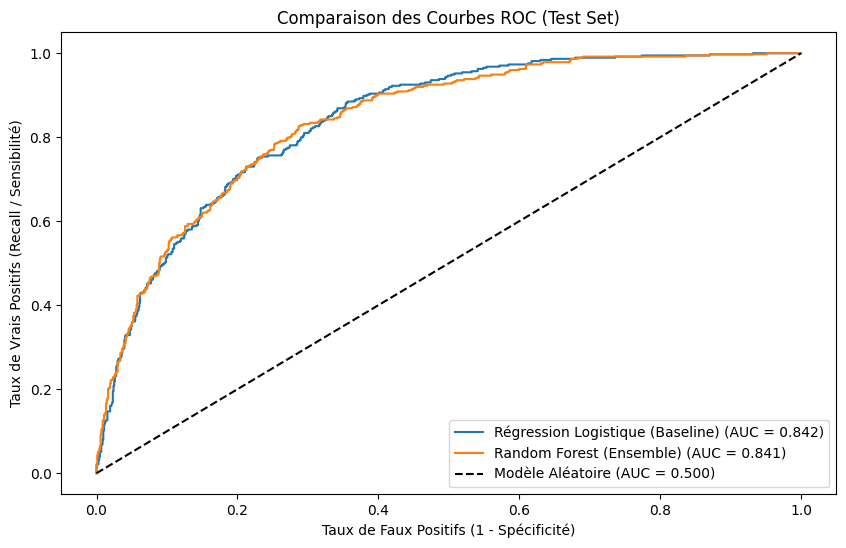

KeyError: 'XGBoost (Boosting)'

In [5]:
# Conversion des résultats en DataFrame pour affichage propre
df_perf = pd.DataFrame(test_results).T[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'F2-Score', 'ROC-AUC']]
print("\n=== TABLEAU COMPARATIF DES PERFORMANCES (TEST SET) ===")
print(df_perf.round(4) * 100)

# --- Visualisation 1 : Courbes ROC ---
plt.figure(figsize=(10, 6))
for name, metrics in test_results.items():
    fpr, tpr, _ = roc_curve(y_test, metrics["y_proba"])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {metrics["ROC-AUC"]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Modèle Aléatoire (AUC = 0.500)')
plt.xlabel('Taux de Faux Positifs (1 - Spécificité)')
plt.ylabel('Taux de Vrais Positifs (Recall / Sensibilité)')
plt.title('Comparaison des Courbes ROC (Test Set)')
plt.legend(loc='lower right')
plt.show()

# --- Visualisation 2 : Matrice de Confusion du Meilleur Modèle (XGBoost généralement) ---
best_model_name = "XGBoost (Boosting)" # Arbitrage basé sur le meilleur compromis F2 / AUC
cm = confusion_matrix(y_test, test_results[best_model_name]["y_pred"])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['Fidèle (0)', 'Churn (1)'],
            yticklabels=['Fidèle (0)', 'Churn (1)'])
plt.title(f"Matrice de Confusion — {best_model_name}")
plt.ylabel('Réalité Terrain')
plt.xlabel('Prédiction Algorithmique')
plt.show()